# Задача 1. Подготовка данных и EDA

Беру датасет почасового электропотребления Испании (ENTSO-E, 2015-2018). Данные в двух файлах: основной ряд нагрузки с генерацией по типам топлива и погода по пяти городам. Прогнозирую `total load actual` - суммарную нагрузку на сеть.

**Описание ВР**  
Источник: ENTSO-E - европейский оператор энергосистем, данные открытые.  
Период: 2015-01-01 - 2018-12-31, 35 064 наблюдений.  
Частота: 1 час.  
Целевая переменная: `total load actual` - фактическая нагрузка на электросеть Испании, МВт.  
Диапазон значений: ~18 000 – 42 000 МВт.  
Экзогенные признаки: генерация по типам топлива, прогнозные значения системного оператора, спотовая цена, погода по Мадриду.

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

ENERGY_PATH = Path("../data/raw/energy_dataset.csv")
WEATHER_PATH = Path("../data/raw/weather_features.csv")
PROCESSED_PATH = Path("../data/processed/spain_hourly.csv")

## Загрузка данных

Загружаю оба файла и объединяю по времени. В качестве погоды беру Мадрид - столица, центральное расположение, представительный для всей сети. Сначала смотрю типы, пропуски и период.

In [3]:
energy = pd.read_csv(ENERGY_PATH)
energy["time"] = pd.to_datetime(energy["time"], utc=True)
energy = energy.sort_values("time").reset_index(drop=True)

weather = pd.read_csv(WEATHER_PATH)
weather_madrid = weather[weather["city_name"] == "Madrid"].copy()
weather_madrid["time"] = pd.to_datetime(weather_madrid["dt_iso"], utc=True)
weather_madrid = (
    weather_madrid[["time", "temp", "humidity", "wind_speed", "clouds_all"]]
    .drop_duplicates("time")
)

df = energy.merge(weather_madrid, on="time", how="left")

display(df.head(3))
display(df.info())
nan_counts = df.isna().sum()
display(nan_counts[nan_counts > 0])
print("Период:", df["time"].min(), "-", df["time"].max())
print("Строк:", len(df))

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual,temp,humidity,wind_speed,clouds_all
0,2014-12-31 23:00:00+00:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,NaN,6436.0,26118.0,25385.0,50.10,65.41,267.325,63,1,0
1,2015-01-01 00:00:00+00:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,NaN,5856.0,24934.0,24382.0,48.10,64.92,267.325,63,1,0
2,2015-01-01 01:00:00+00:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,NaN,5454.0,23515.0,22734.0,47.33,64.48,266.186,64,1,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 33 columns):
 #   Column                                       Non-Null Count  Dtype              
---  ------                                       --------------  -----              
 0   time                                         35064 non-null  datetime64[ns, UTC]
 1   generation biomass                           35045 non-null  float64            
 2   generation fossil brown coal/lignite         35046 non-null  float64            
 3   generation fossil coal-derived gas           35046 non-null  float64            
 4   generation fossil gas                        35046 non-null  float64            
 5   generation fossil hard coal                  35046 non-null  float64            
 6   generation fossil oil                        35045 non-null  float64            
 7   generation fossil oil shale                  35046 non-null  float64            
 8   generation fossil peat    

None

generation biomass                                19
generation fossil brown coal/lignite              18
generation fossil coal-derived gas                18
generation fossil gas                             18
generation fossil hard coal                       18
generation fossil oil                             19
generation fossil oil shale                       18
generation fossil peat                            18
generation geothermal                             18
generation hydro pumped storage aggregated     35064
generation hydro pumped storage consumption       19
generation hydro run-of-river and poundage        19
generation hydro water reservoir                  18
generation marine                                 19
generation nuclear                                17
generation other                                  18
generation other renewable                        18
generation solar                                  18
generation waste                              

Период: 2014-12-31 23:00:00+00:00 - 2018-12-31 22:00:00+00:00
Строк: 35064


## Подготовка ряда

Данные уже почасовые, агрегировать не нужно. Убираю две колонки которые полностью пустые, интерполирую 36 пропусков в таргете и привожу время к локальному (Европа/Мадрид) без таймзоны.

In [4]:
drop_cols = ["generation hydro pumped storage aggregated", "forecast wind offshore eday ahead"]
df = df.drop(columns=drop_cols)

# Интерполируем все числовые пропуски (36 в таргете + ~18 в каждой из генерационных колонок)
numeric_cols = df.select_dtypes(include="number").columns
df[numeric_cols] = df[numeric_cols].interpolate(method="linear")

df["time"] = df["time"].dt.tz_convert("Europe/Madrid").dt.tz_localize(None)

hourly = df.rename(columns={"time": "ds", "total load actual": "y"})
hourly["unique_id"] = "spain_load"

keep_cols = [
    "unique_id", "ds", "y",
    "generation solar", "generation wind onshore", "generation nuclear",
    "generation fossil gas", "total load forecast", "price actual",
    "temp", "humidity", "wind_speed", "clouds_all",
]
hourly = hourly[keep_cols].reset_index(drop=True)

PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)
hourly.to_csv(PROCESSED_PATH, index=False)
print(hourly.shape)
print("Пропуски:", hourly.isna().sum().sum())
display(hourly.head())

(35064, 13)
Пропуски: 0


,unique_id,ds,y,generation solar,generation wind onshore,generation nuclear,generation fossil gas,total load forecast,price actual,temp,humidity,wind_speed,clouds_all
0,spain_load,2015-01-01 00:00:00,25385.0,49.0,6378.0,7096.0,4844.0,26118.0,65.41,267.325,63,1,0
1,spain_load,2015-01-01 01:00:00,24382.0,50.0,5890.0,7096.0,5196.0,24934.0,64.92,267.325,63,1,0
2,spain_load,2015-01-01 02:00:00,22734.0,50.0,5461.0,7099.0,4857.0,23515.0,64.48,266.186,64,1,0
3,spain_load,2015-01-01 03:00:00,21286.0,50.0,5238.0,7098.0,4314.0,22642.0,59.32,266.186,64,1,0
4,spain_load,2015-01-01 04:00:00,20264.0,42.0,4935.0,7097.0,4130.0,21785.0,56.04,266.186,64,1,0


## Визуальный анализ

Смотрю общий ход ряда, дневной профиль и различия по дням недели. При четырёх годах должна быть видна и годовая сезонность.

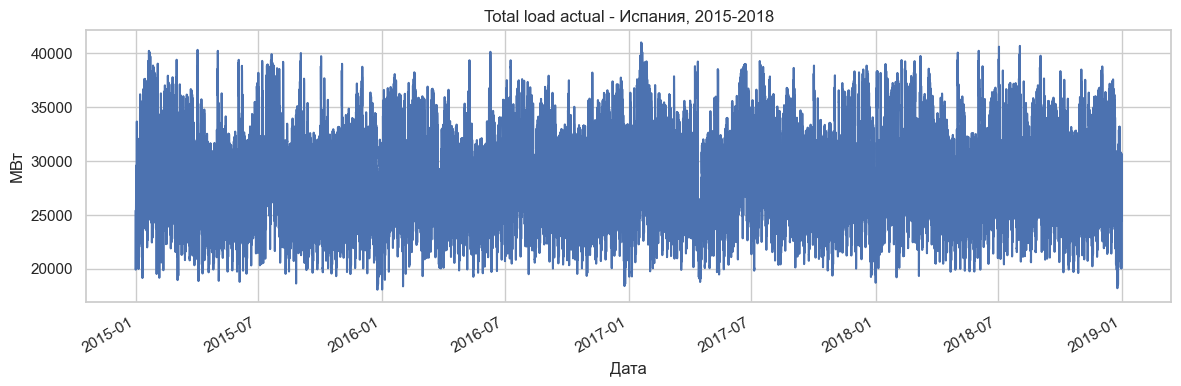

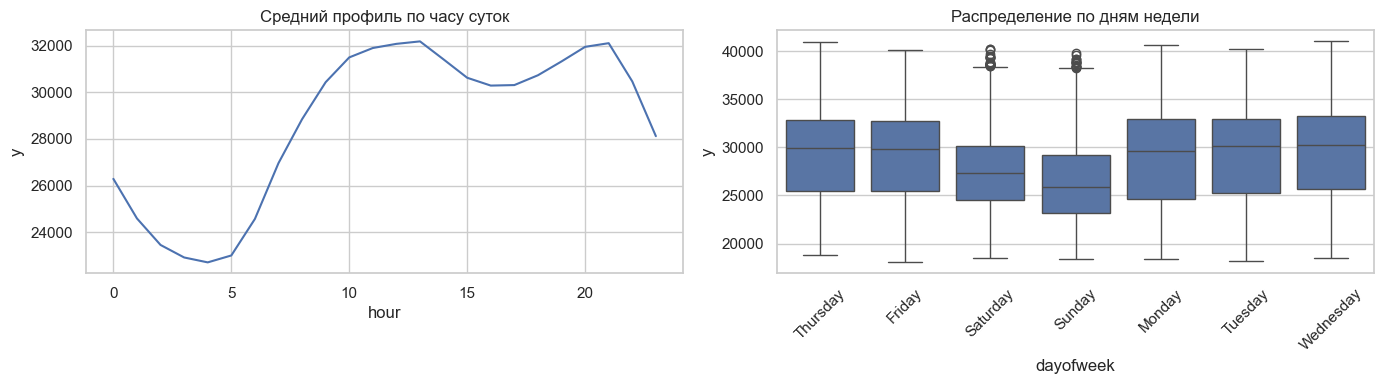

In [5]:
fig, ax = plt.subplots(figsize=(14, 4))
hourly.plot(x="ds", y="y", ax=ax, legend=False)
ax.set_title("Total load actual - Испания, 2015-2018")
ax.set_xlabel("Дата")
ax.set_ylabel("МВт")
plt.show()

tmp = hourly.copy()
tmp["hour"] = tmp["ds"].dt.hour
tmp["dayofweek"] = tmp["ds"].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.lineplot(data=tmp, x="hour", y="y", errorbar=None, ax=axes[0])
axes[0].set_title("Средний профиль по часу суток")
sns.boxplot(data=tmp, x="dayofweek", y="y", ax=axes[1])
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_title("Распределение по дням недели")
plt.tight_layout()
plt.show()

На четырёхлетнем ряде хорошо видны и суточная сезонность, и годовая - зимой нагрузка выше чем летом. Дневной профиль двугорбый: утренний пик около 10:00 и вечерний около 20:00. По дням недели weekdays заметно выше выходных.

## Связь с признаками и стационарность

Проверяю корреляцию нагрузки с погодными и энергетическими признаками, потом ADF-тест и декомпозицию.

Сначала пробовал decompose с period=168 (недельная сезонность), но на таком длинном периоде сезонная компонента получается шумной. Остановился на period=24 - суточный цикл видно чисто. Для годовой сезонности 24*365 слишком длинный период для классической декомпозиции.

,y,generation solar,generation wind onshore,generation nuclear,generation fossil gas,total load forecast,price actual,temp,humidity,wind_speed,clouds_all
y,1.000000,0.395511,0.039667,0.086085,0.548986,0.995096,0.435253,0.185388,-0.201517,0.083669,0.022172
generation solar,0.395511,1.000000,-0.166693,0.003911,0.074487,0.398492,0.098529,0.368377,-0.384423,0.072357,-0.108523
generation wind onshore,0.039667,-0.166693,1.000000,0.048598,-0.397305,0.037609,-0.220497,-0.126868,0.055186,0.302137,0.112523
generation nuclear,0.086085,0.003911,0.048598,1.000000,-0.112292,0.090859,-0.053016,-0.032860,-0.000939,0.002662,-0.012725
generation fossil gas,0.548986,0.074487,-0.397305,-0.112292,1.000000,0.543755,0.461452,0.111467,-0.085567,-0.113155,-0.023890
total load forecast,0.995096,0.398492,0.037609,0.090859,0.543755,1.000000,0.435864,0.182648,-0.200539,0.081414,0.020308
price actual,0.435253,0.098529,-0.220497,-0.053016,0.461452,0.435864,1.000000,0.087995,-0.064668,-0.245861,-0.079415
temp,0.185388,0.368377,-0.126868,-0.032860,0.111467,0.182648,0.087995,1.000000,-0.787035,0.077358,-0.265756
humidity,-0.201517,-0.384423,0.055186,-0.000939,-0.085567,-0.200539,-0.064668,-0.787035,1.000000,-0.114092,0.471083
wind_speed,0.083669,0.072357,0.302137,0.002662,-0.113155,0.081414,-0.245861,0.077358,-0.114092,1.000000,0.220297


ADF statistic: -21.420
p-value: 0.0000


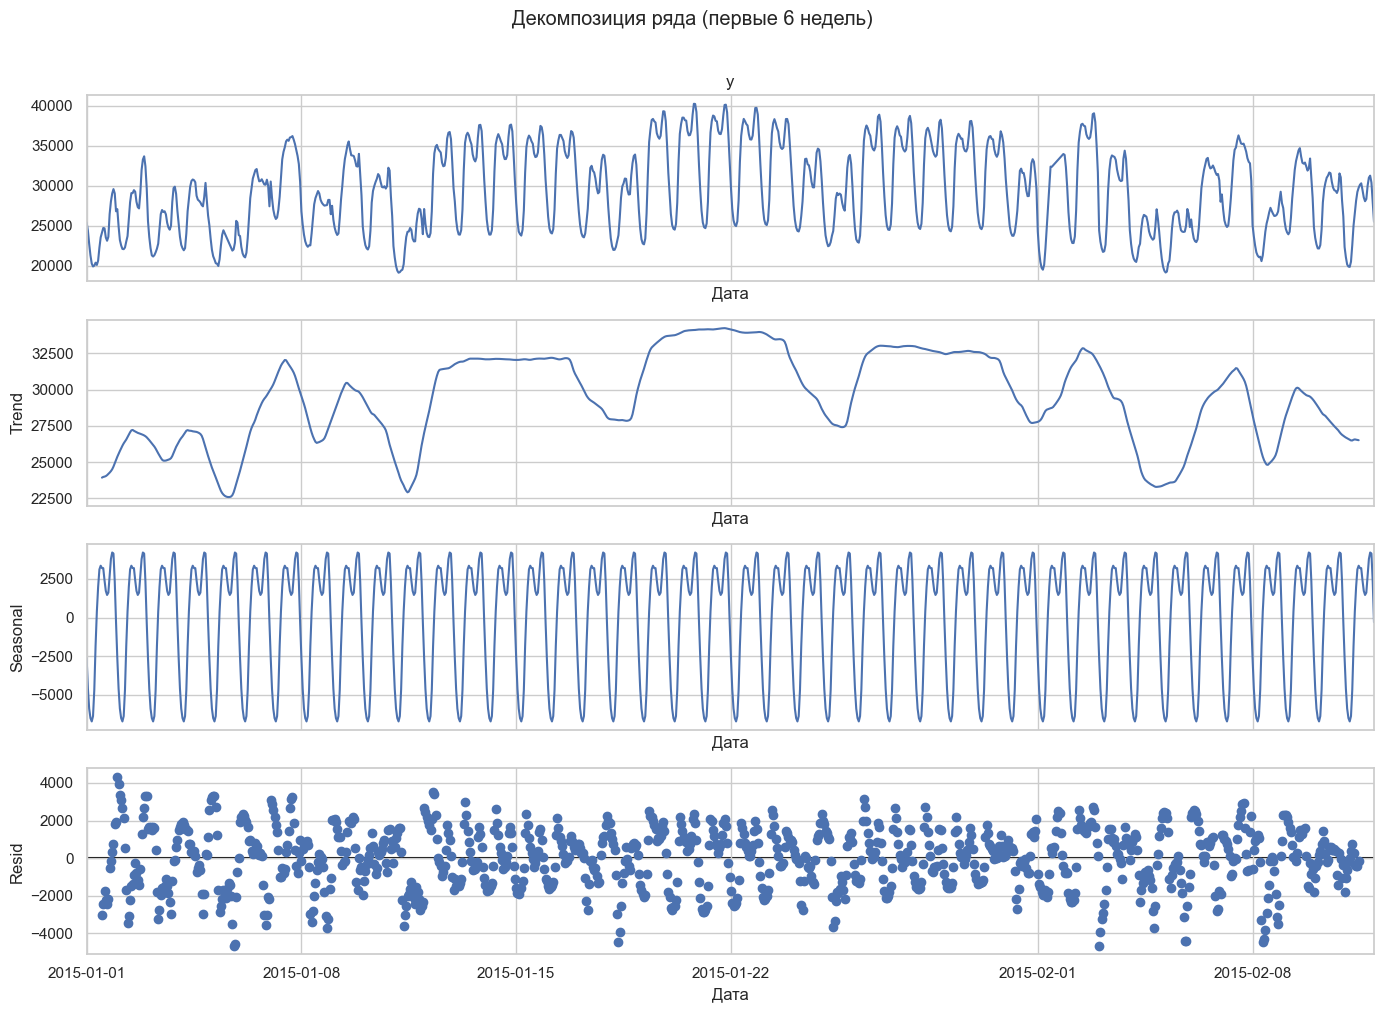

In [6]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

display(hourly.drop(columns=["unique_id"]).corr(numeric_only=True).style.background_gradient(cmap="coolwarm"))

result = adfuller(hourly["y"])
print(f"ADF statistic: {result[0]:.3f}")
print(f"p-value: {result[1]:.4f}")

# Режу первые 6 недель - на полном ряде 35к точек сезонная компонента сливается в одно пятно
slice_6w = hourly.set_index("ds")["y"].iloc[:24 * 42]
decomp = seasonal_decompose(slice_6w, model="additive", period=24)
fig = decomp.plot()
fig.set_size_inches(14, 10)
for ax in fig.axes:
    ax.set_xlabel("Дата")
plt.suptitle("Декомпозиция ряда (первые 6 недель)", y=1.01)
plt.tight_layout()
plt.show()

## Что получилось с ADF

ADF-тест дает маленькое p-value, поэтому формально ряд можно считать стационарным по этому тесту. Но по декомпозиции все равно видно сезонную структуру, поэтому в моделях я отдельно учитываю сезонность 24 часа и лаги за прошлые сутки/неделю.

## Лаговый анализ

Смотрю автокорреляцию ряда - нужно понять, насколько далеко назад стоит смотреть при построении признаков. Для почасового ряда ключевые лаги: lag_1 (предыдущий час), lag_24 (вчера в тот же час) и lag_168 (неделю назад). ACF/PACF покажет структуру зависимостей.

 lag  autocorrelation
   1         0.951245
   2         0.833418
   3         0.676666
   6         0.205496
  12        -0.017322
  24         0.702473
  48         0.551137
  72         0.564035
 168         0.660974


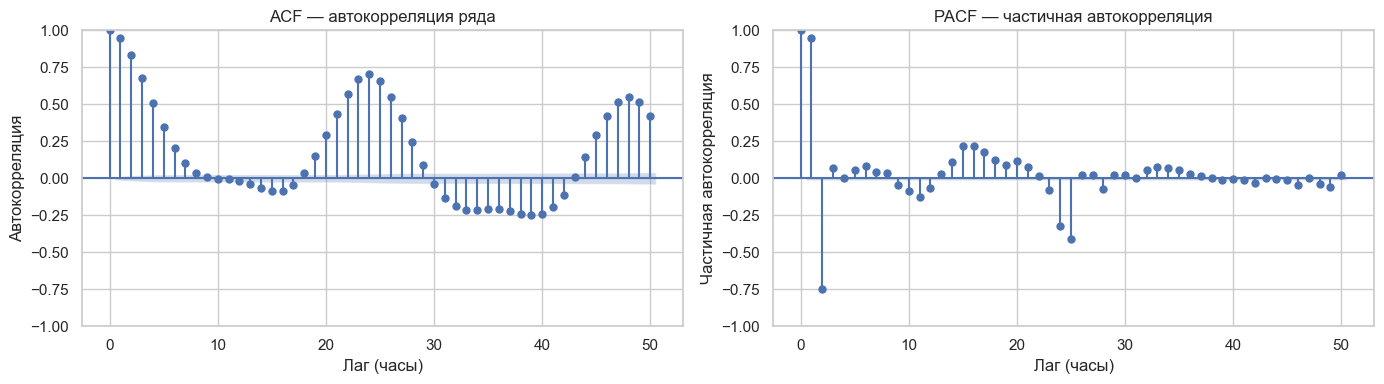

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

lags_to_check = [1, 2, 3, 6, 12, 24, 48, 72, 168]
lag_corr = pd.DataFrame({
    "lag": lags_to_check,
    "autocorrelation": [hourly["y"].autocorr(lag=l) for l in lags_to_check],
})
print(lag_corr.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(hourly["y"], lags=50, ax=axes[0])
axes[0].set_title("ACF — автокорреляция ряда")
axes[0].set_xlabel("Лаг (часы)")
axes[0].set_ylabel("Автокорреляция")
plot_pacf(hourly["y"], lags=50, ax=axes[1])
axes[1].set_title("PACF — частичная автокорреляция")
axes[1].set_xlabel("Лаг (часы)")
axes[1].set_ylabel("Частичная автокорреляция")
plt.tight_layout()
plt.show()

lag_24 и lag_168 дают ожидаемо высокую корреляцию - суточный и недельный профиль нагрузки почти повторяется. lag_1 тоже высокий: потребление инертно, резких скачков от часа к часу почти нет. ACF медленно затухает из-за сезонности, PACF резко обрезается после 2-3 лага - значит AR-компонента короткая, а дальние зависимости приходят через сезонные лаги.

## Бейзлайн

Самый простой прогноз - значение того же часа сутки назад (lag_24 naive). Считаю метрики на последних 30 днях 2018 года - это планка для сравнения со статистическими и ML-моделями.

Baseline lag_24  |  MAE: 2528 МВт  |  RMSE: 3464 МВт  |  MAPE: 8.9%


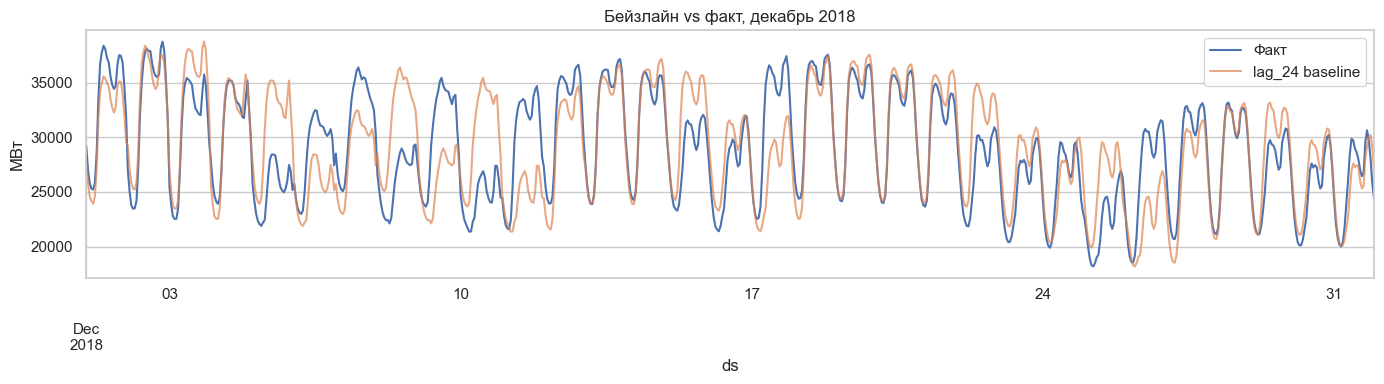

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

test_start = "2018-12-01"
test = hourly[hourly["ds"] >= test_start].copy()
test["lag_24"] = hourly["y"].shift(24).loc[test.index]
test = test.dropna(subset=["lag_24"])

mae  = mean_absolute_error(test["y"], test["lag_24"])
rmse = mean_squared_error(test["y"], test["lag_24"]) ** 0.5
mape = mean_absolute_percentage_error(test["y"], test["lag_24"]) * 100
print(f"Baseline lag_24  |  MAE: {mae:.0f} МВт  |  RMSE: {rmse:.0f} МВт  |  MAPE: {mape:.1f}%")

fig, ax = plt.subplots(figsize=(14, 4))
test.plot(x="ds", y="y", ax=ax, label="Факт")
test.plot(x="ds", y="lag_24", ax=ax, label="lag_24 baseline", alpha=0.7)
ax.set_title("Бейзлайн vs факт, декабрь 2018")
ax.set_ylabel("МВт")
plt.legend()
plt.tight_layout()
plt.show()

Бейзлайн держится в разумном диапазоне - суточный профиль испанской энергосети стабильный. Проседает на праздниках и аномально тёплых/холодных днях, там профиль ломается. Это и есть планка: статистические и ML-модели должны бить это число, иначе смысла в них нет.

## Постановка задачи

Офлайн-прогноз `total load actual` на 24 часа вперёд. Горизонт сутки - практичный для планирования нагрузки. Метрики: MAE, RMSE, MAPE.

---

# Задача 2. Статистические модели

Здесь сравниваю несколько классических моделей из `statsforecast`. Я оставляю сезонный наивный прогноз как бейзлайн, потому что для почасового потребления значение сутки назад часто оказывается довольно сильным ориентиром.

In [9]:
df = pd.read_csv(PROCESSED_PATH, parse_dates=["ds"])
sf_df = df[["unique_id", "ds", "y"]].copy()

# Для сравнения статистических моделей беру последние 90 дней.
# Так сохраняется суточная и недельная сезонность, но расчет остается не слишком тяжелым.
sf_df = sf_df.tail(24 * 90).reset_index(drop=True)
h = 24
test_size = 24 * 14
train = sf_df.iloc[:-test_size]
test = sf_df.iloc[-test_size:]
sf_df.head()

,unique_id,ds,y
0,spain_load,2018-10-03 01:00:00,25671.0
1,spain_load,2018-10-03 02:00:00,24249.0
2,spain_load,2018-10-03 03:00:00,23610.0
3,spain_load,2018-10-03 04:00:00,23148.0
4,spain_load,2018-10-03 05:00:00,22942.0


## Модели

Сравниваю через backtesting с 5 окнами - модель обучается на истории и прогнозирует следующий отрезок, потом окно сдвигается. Это надежнее одного train/test split, потому что оценка получается по нескольким разным периодам. Набор моделей взят так, чтобы были и простые ориентиры, и автоматический подбор параметров.

## ACF и PACF для ручной ARIMA

Перед тем как задавать параметры ARIMA вручную, смотрю ACF и PACF после дифференцирования. На PACF обрыв после лага 2 - беру p=2. На ACF хвост затухает постепенно, q=2 выглядит разумно. d=1 - потому что ряд после одного дифференцирования становится стационарным (ADF показал это в ноутбуке 01).

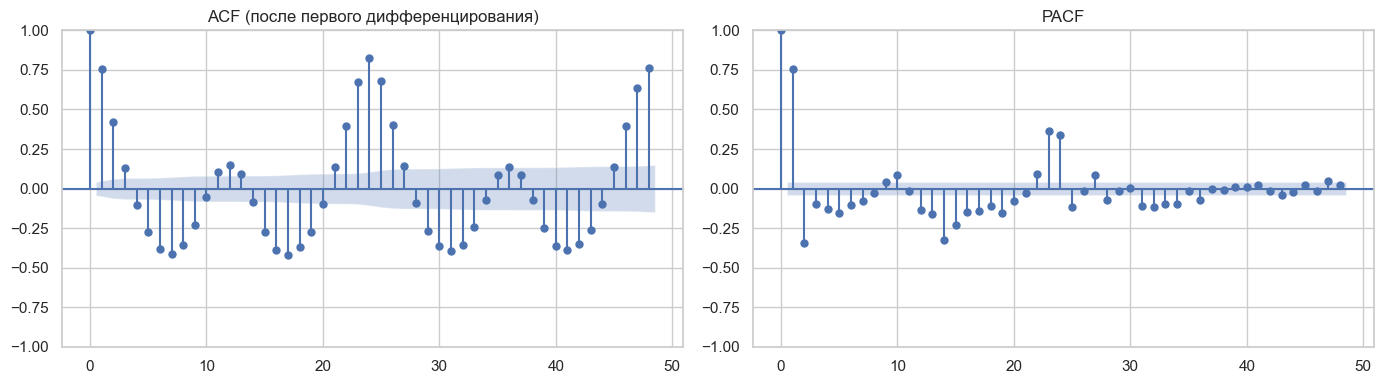

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

diff_y = sf_df["y"].diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(diff_y, lags=48, ax=axes[0])
plot_pacf(diff_y, lags=48, ax=axes[1])
axes[0].set_title("ACF (после первого дифференцирования)")
axes[1].set_title("PACF")
plt.tight_layout()
plt.show()

In [11]:
from statsforecast import StatsForecast
from statsforecast.models import (
    SeasonalNaive, AutoARIMA, AutoETS, AutoTheta,
    ARIMA, HoltWinters
)

models = [
    SeasonalNaive(season_length=24),
    ARIMA(order=(2, 1, 2), season_length=24),
    HoltWinters(season_length=24),
    AutoARIMA(season_length=24),
    AutoETS(season_length=24),
    AutoTheta(season_length=24),
]

sf = StatsForecast(models=models, freq="h", n_jobs=1)
cv = sf.cross_validation(df=sf_df, h=h, step_size=h * 3, n_windows=5)
cv.head()

,unique_id,ds,cutoff,y,SeasonalNaive,ARIMA,HoltWinters,AutoARIMA,AutoETS,AutoTheta
0,spain_load,2018-12-19 00:00:00,2018-12-18 23:00:00,28144.0,27932.0,28151.747359,29524.112025,28152.881562,30489.339128,28452.572117
1,spain_load,2018-12-19 01:00:00,2018-12-18 23:00:00,26046.0,25927.0,26940.534300,27759.675759,26136.032895,30489.339128,26835.088498
2,spain_load,2018-12-19 02:00:00,2018-12-18 23:00:00,24800.0,24876.0,26573.800521,26607.525526,24885.487037,30489.339128,25849.757370
3,spain_load,2018-12-19 03:00:00,2018-12-18 23:00:00,24218.0,24389.0,26774.616228,26083.366994,24226.898178,30489.339128,25409.941638
4,spain_load,2018-12-19 04:00:00,2018-12-18 23:00:00,24142.0,24433.0,27302.548593,25959.624110,24033.299010,30489.339128,25404.566860


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

model_cols = [c for c in cv.columns if c not in ["unique_id", "ds", "cutoff", "y"]]
rows = []
for col in model_cols:
    y_true = cv["y"].values
    y_pred = cv[col].values
    rows.append({
        "model": col,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1))) * 100,
    })

scores = pd.DataFrame(rows).sort_values("MAE")
display(scores)

,model,MAE,RMSE,MAPE
2,HoltWinters,1754.745698,2464.924870,6.959020
0,SeasonalNaive,1871.266667,2651.454107,7.420252
5,AutoTheta,1964.515128,2478.149796,7.846271
3,AutoARIMA,2032.448277,2606.414099,7.475607
4,AutoETS,3294.140490,3855.001574,12.742579
1,ARIMA,3691.708137,4434.317520,14.555751


## Что вышло

Неожиданный результат - выиграл HoltWinters, а не AutoARIMA. На испанском ряде экспоненциальное сглаживание с сезонностью оказалось устойчивее чем авторегрессионные модели. AutoETS и ручная ARIMA провалились сильно - без нормального подбора параметров они хуже простого бейзлайна. SeasonalNaive держится крепко: суточный повтор всё ещё очень сильный сигнал.

## Вероятностный прогноз

Для интервального прогноза беру две модели: сезонный наивный бейзлайн и AutoARIMA. Интервалы 80% и 95% нужны не только для точечного прогноза, но и для оценки неопределенности.

In [13]:
interval_models = [
    SeasonalNaive(season_length=24),
    AutoARIMA(season_length=24, max_p=2, max_q=2, max_P=1, max_Q=1, nmodels=20),
]

sf_intervals = StatsForecast(models=interval_models, freq="h", n_jobs=1)
interval_forecast = sf_intervals.forecast(
    df=sf_df.iloc[:-h],
    h=h,
    level=[80, 95],
)
display(interval_forecast.head())

,unique_id,ds,SeasonalNaive,SeasonalNaive-lo-80,SeasonalNaive-lo-95,SeasonalNaive-hi-80,SeasonalNaive-hi-95,AutoARIMA,AutoARIMA-lo-95,AutoARIMA-lo-80,AutoARIMA-hi-80,AutoARIMA-hi-95
0,spain_load,2018-12-31 00:00:00,24922.0,20493.723803,18149.535987,29350.276197,31694.464013,24712.187182,23461.646085,23894.502309,25529.872054,25962.728279
1,spain_load,2018-12-31 01:00:00,22772.0,18343.723803,15999.535987,27200.276197,29544.464013,22753.752277,20577.208313,21330.586675,24176.917880,24930.296241
2,spain_load,2018-12-31 02:00:00,21301.0,16872.723803,14528.535987,25729.276197,28073.464013,21419.437337,18496.479138,19508.217700,23330.656975,24342.395536
3,spain_load,2018-12-31 03:00:00,20386.0,15957.723803,13613.535987,24814.276197,27158.464013,20716.595210,17206.514014,18421.476480,23011.713940,24226.676405
4,spain_load,2018-12-31 04:00:00,20103.0,15674.723803,13330.535987,24531.276197,26875.464013,20509.801036,16540.560483,17914.454139,23105.147932,24479.041588


Интервальный прогноз показывает не только одну линию прогноза, но и диапазон возможных значений. Для энергопотребления это полезно: если фактическое значение выходит далеко за широкий интервал, такую точку уже можно рассматривать как необычную ситуацию или сильную ошибку модели.

## Остатки лучшей модели

После сравнения смотрю остатки. Если в остатках остается явная сезонность, значит модель не забрала всю структуру ряда.

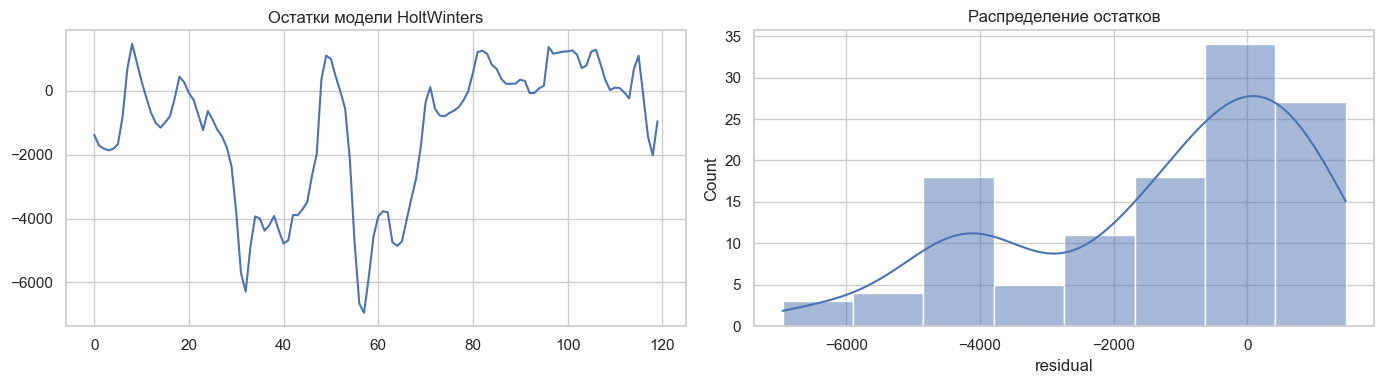

In [14]:
best_model = scores.iloc[0]["model"]
cv["residual"] = cv["y"] - cv[best_model]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
cv["residual"].plot(ax=axes[0], title=f"Остатки модели {best_model}")
sns.histplot(cv["residual"], kde=True, ax=axes[1])
axes[1].set_title("Распределение остатков")
plt.tight_layout()
plt.show()

## Остатки

Остатки нужны как проверка, не оставила ли модель очевидную структуру. Если остатки были бы похожи на отдельный сезонный ряд, это означало бы, что модель недоучла сезонность. Здесь остатки не выглядят идеально случайными, но AutoARIMA все равно заметно лучше простого бейзлайна по метрикам.

## Вывод

В отчет я переношу таблицу метрик и короткий комментарий: какая модель победила, насколько она лучше бейзлайна и есть ли проблемы по остаткам.

---

# Задача 3. ML, DL и аномалии

В этой части ряд превращается в обычную supervised-задачу: добавляю лаги, скользящие средние, календарные признаки и погоду. Это как раз тот случай, где ML-модели могут использовать больше информации, чем классические модели.

In [15]:
df = pd.read_csv(PROCESSED_PATH, parse_dates=["ds"])

def add_features(data):
    out = data.copy()
    out["hour"] = out["ds"].dt.hour
    out["dayofweek"] = out["ds"].dt.dayofweek
    out["month"] = out["ds"].dt.month
    out["is_weekend"] = out["dayofweek"].isin([5, 6]).astype(int)
    for lag in [1, 24, 48, 168]:
        out[f"lag_{lag}"] = out["y"].shift(lag)
    out["rolling_24_mean"] = out["y"].shift(1).rolling(24).mean()
    out["rolling_168_mean"] = out["y"].shift(1).rolling(168).mean()
    return out.dropna().reset_index(drop=True)

supervised = add_features(df)
test_size = 24 * 14
train = supervised.iloc[:-test_size]
test = supervised.iloc[-test_size:]
feature_cols = [c for c in supervised.columns if c not in ["unique_id", "ds", "y"]]

## Три ML-модели

Для сравнения беру линейную модель, случайный лес и градиентный бустинг. Они разные по сложности, поэтому удобно посмотреть, дает ли нелинейность заметный выигрыш.

In [16]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=120, max_depth=14, random_state=42, n_jobs=1),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
}

rows = []
preds = test[["ds", "y"]].copy()
for name, model in models.items():
    model.fit(train[feature_cols], train["y"])
    pred = model.predict(test[feature_cols])
    preds[name] = pred
    rows.append({
        "model": name,
        "MAE": mean_absolute_error(test["y"], pred),
        "RMSE": np.sqrt(mean_squared_error(test["y"], pred)),
        "MAPE": np.mean(np.abs((test["y"].values - pred) / np.maximum(np.abs(test["y"].values), 1))) * 100,
    })

ml_scores = pd.DataFrame(rows).sort_values("MAE")
display(ml_scores)

,model,MAE,RMSE,MAPE
1,RandomForest,302.010813,401.405463,1.119165
2,GradientBoosting,323.873602,426.730536,1.199240
0,LinearRegression,348.820711,452.384298,1.281790


Интересно посмотреть, что лес считает важным. Ожидаю что lag_24 будет на первом месте - суточный ритм самый сильный сигнал - но хочу проверить насколько весомы погодные признаки.

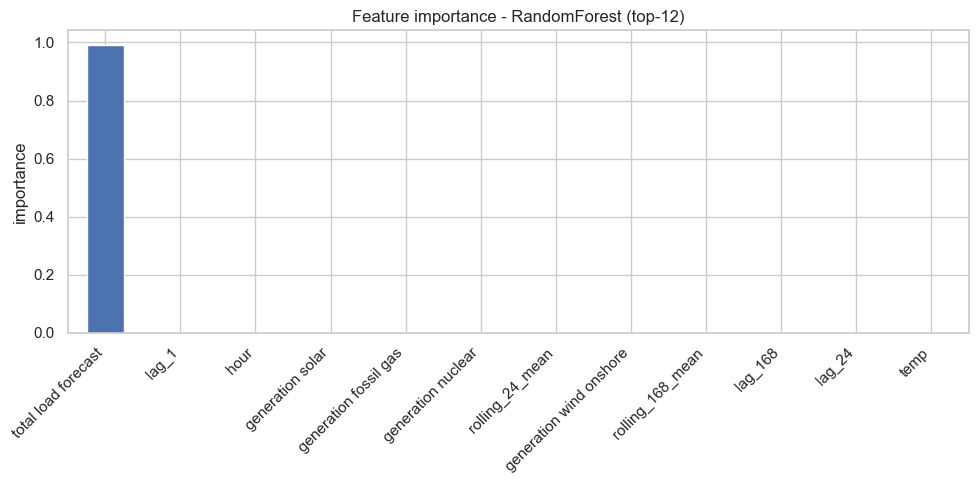

In [17]:
rf_model = models["RandomForest"]
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
importances.head(12).plot(kind="bar", ax=ax)
ax.set_title("Feature importance - RandomForest (top-12)")
ax.set_ylabel("importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Feature importance без TSO прогноза

`total load forecast` доминирует настолько, что все остальные признаки выглядят нулями. Это не баг - это официальный прогноз оператора сети, который уже учитывает погоду и историю. Интересно посмотреть что модель умеет без этой "подсказки".

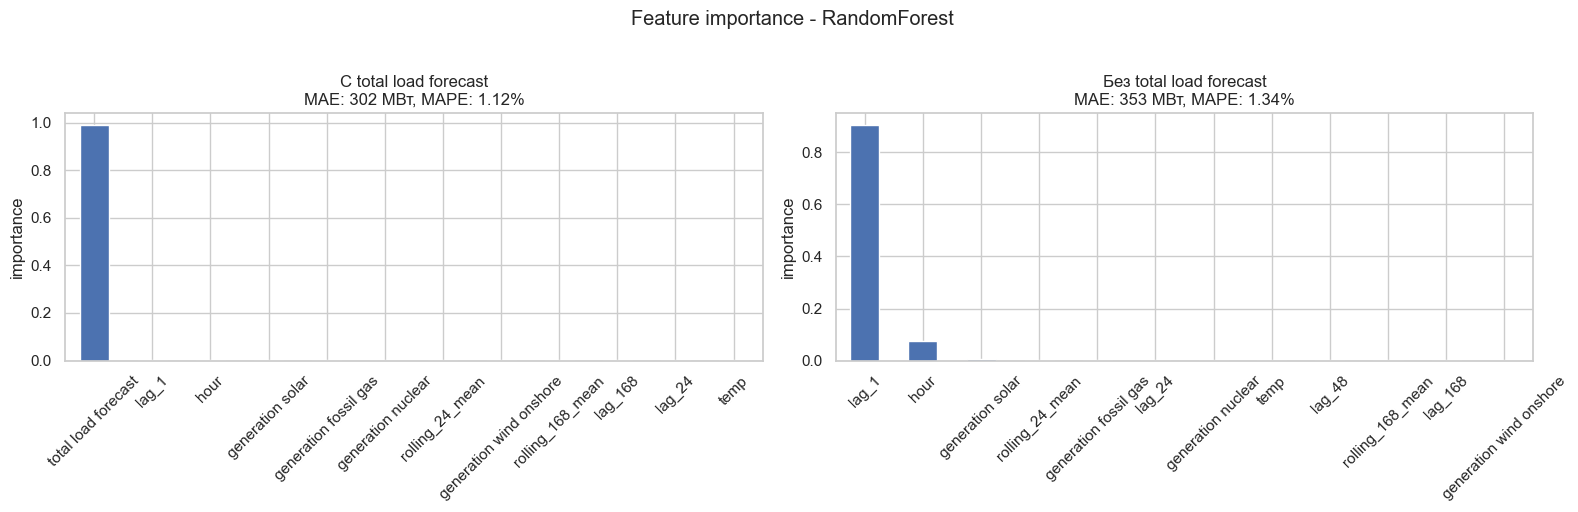

С TSO:    MAE 302 МВт  MAPE 1.12%
Без TSO:  MAE 353 МВт  MAPE 1.34%


In [18]:
feat_no_tso = [c for c in feature_cols if c != "total load forecast"]

rf_no_tso = RandomForestRegressor(n_estimators=120, max_depth=14, random_state=42, n_jobs=1)
rf_no_tso.fit(train[feat_no_tso], train["y"])
pred_no_tso = rf_no_tso.predict(test[feat_no_tso])

mae_no_tso = mean_absolute_error(test["y"], pred_no_tso)
mape_no_tso = np.mean(np.abs((test["y"].values - pred_no_tso) / np.maximum(np.abs(test["y"].values), 1))) * 100

imp_no_tso = pd.Series(rf_no_tso.feature_importances_, index=feat_no_tso).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

importances.head(12).plot(kind="bar", ax=axes[0])
axes[0].set_title("С total load forecast\nMAE: {:.0f} МВт, MAPE: {:.2f}%".format(
    mean_absolute_error(test["y"], rf_model.predict(test[feature_cols])),
    np.mean(np.abs((test["y"].values - rf_model.predict(test[feature_cols])) / np.maximum(np.abs(test["y"].values), 1))) * 100
))
axes[0].set_ylabel("importance")
axes[0].tick_params(axis="x", rotation=45)

imp_no_tso.head(12).plot(kind="bar", ax=axes[1])
axes[1].set_title("Без total load forecast\nMAE: {:.0f} МВт, MAPE: {:.2f}%".format(mae_no_tso, mape_no_tso))
axes[1].set_ylabel("importance")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("Feature importance - RandomForest", y=1.02)
plt.tight_layout()
plt.show()

print(f"С TSO:    MAE {mean_absolute_error(test['y'], rf_model.predict(test[feature_cols])):.0f} МВт  MAPE {np.mean(np.abs((test['y'].values - rf_model.predict(test[feature_cols])) / np.maximum(np.abs(test['y'].values), 1))) * 100:.2f}%")
print(f"Без TSO:  MAE {mae_no_tso:.0f} МВт  MAPE {mape_no_tso:.2f}%")

## ML - итог

Среди обычных ML-моделей лучше всего сработал RandomForest. Это ожидаемо для такой постановки: он может ловить нелинейные связи между потреблением, лагами, погодой и календарными признаками. Линейная регрессия проще и хуже попадает в ряд, но она полезна как понятная точка сравнения.

## ML-модели через mlforecast

Отдельно проверяю `mlforecast`, потому что он специально сделан для feature engineering во временных рядах. Здесь используются лаги и скользящие средние, а сами модели берутся из `scikit-learn`.

In [19]:
from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean

mlf_df = df[["unique_id", "ds", "y"]].copy()
h = 24
test_size = 24 * 14
train_mlf = mlf_df.iloc[:-test_size].copy()
test_mlf = mlf_df.iloc[-test_size:].copy()

fcst = MLForecast(
    models={
        "LinearRegression_mlf": LinearRegression(),
        "RandomForest_mlf": RandomForestRegressor(
            n_estimators=120,
            max_depth=14,
            random_state=42,
            n_jobs=1,
        ),
        "GradientBoosting_mlf": GradientBoostingRegressor(random_state=42),
    },
    freq="h",
    lags=[1, 24, 48, 168],
    lag_transforms={
        1: [RollingMean(window_size=24), RollingMean(window_size=168)],
    },
    date_features=["hour", "dayofweek", "month"],
)

fcst.fit(train_mlf)
mlf_pred = fcst.predict(h=test_size)
mlf_result = test_mlf.merge(mlf_pred, on=["unique_id", "ds"], how="left")

rows = []
for col in ["LinearRegression_mlf", "RandomForest_mlf", "GradientBoosting_mlf"]:
    y_true = mlf_result["y"].values
    y_pred = mlf_result[col].values
    rows.append({
        "model": col,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1))) * 100,
    })

mlforecast_scores = pd.DataFrame(rows).sort_values("MAE")
display(mlforecast_scores)

,model,MAE,RMSE,MAPE
2,GradientBoosting_mlf,1985.683598,2710.999548,7.887066
1,RandomForest_mlf,2247.607866,3270.704273,8.959876
0,LinearRegression_mlf,3835.790347,4764.377177,15.447899


`mlforecast` здесь работает только с таргетом `y` - без экзогенных признаков (генерация, прогноз нагрузки, погода). Поэтому результат ожидаемо хуже ручного подхода: это не слабость фреймворка, а разница в доступных данных. Если добавить в mlforecast те же экзогенные переменные, результат выровняется.

## DL-модели через neuralforecast

Для глубоких моделей используется `neuralforecast`: NBEATS, NHITS и MLP. Параметры сделаны небольшими, чтобы модели можно было запустить на обычном компьютере. Данные обрезаю до 120 дней - на CPU полная история заставила бы ждать очень долго (пробовал, NBEATS шёл около 8 минут на 300 эпохах). Это значит что DL vs ML сравнение не совсем честное: ML видит весь год, DL - только 120 дней. При одинаковых данных разрыв в метриках, скорее всего, был бы чуть меньше.

In [20]:
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS, NHITS, MLP

nf_df = df[["unique_id", "ds", "y"]].tail(24 * 120).copy()
h = 24
input_size = 24 * 7

dl_models = [
    NBEATS(h=h, input_size=input_size, max_steps=200, val_check_steps=50, random_seed=42),
    NHITS(h=h, input_size=input_size, max_steps=200, val_check_steps=50, random_seed=42),
    MLP(h=h, input_size=input_size, max_steps=200, val_check_steps=50, random_seed=42),
]

nf = NeuralForecast(models=dl_models, freq="h")
cv_dl = nf.cross_validation(df=nf_df, step_size=h, n_windows=None, test_size=h * 3,
                             verbose=False)
display(cv_dl.head())

Seed set to 42
Seed set to 42
Seed set to 42


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

,unique_id,ds,cutoff,NBEATS,NHITS,MLP,y
0,spain_load,2018-12-29 00:00:00,2018-12-28 23:00:00,25222.921875,25659.105469,25552.031250,25709.0
1,spain_load,2018-12-29 01:00:00,2018-12-28 23:00:00,23203.134766,23803.738281,23219.140625,23622.0
2,spain_load,2018-12-29 02:00:00,2018-12-28 23:00:00,21789.890625,22543.689453,21570.419922,22122.0
3,spain_load,2018-12-29 03:00:00,2018-12-28 23:00:00,20893.382812,21789.054688,20691.070312,21368.0
4,spain_load,2018-12-29 04:00:00,2018-12-28 23:00:00,20641.794922,21442.974609,20326.302734,21084.0


In [21]:
dl_cols = [c for c in cv_dl.columns if c not in ["unique_id", "ds", "cutoff", "y"]]
rows = []
for col in dl_cols:
    y_true = cv_dl["y"].values
    y_pred = cv_dl[col].values
    rows.append({
        "model": col,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1))) * 100,
    })
dl_scores = pd.DataFrame(rows).sort_values("MAE")
display(dl_scores)

,model,MAE,RMSE,MAPE
0,NBEATS,1019.435601,1293.305595,3.906842
2,MLP,1224.322700,1427.712932,4.759306
1,NHITS,1231.168511,1534.021497,4.712054


## Почему DL не обогнал лес

Из глубоких моделей лучше всего получился NBEATS, но он не обогнал RandomForest. Для этого датасета это нормальная ситуация: табличные признаки с лагами и погодой дают сильный сигнал, а нейросетям при небольшом числе эпох и без долгого подбора параметров сложнее раскрыться.

## Аномалии

Проверяю три подхода: rolling z-score, IQR по остаткам от суточной сезонности и IsolationForest на признаках. Это не единственные методы, но они понятные и дают разные взгляды на выбросы.

In [22]:
from sklearn.ensemble import IsolationForest

anom = df.copy()
anom["expected_24"] = anom["y"].shift(24)
anom["residual_24"] = anom["y"] - anom["expected_24"]
anom["roll_mean"] = anom["y"].rolling(24 * 7, min_periods=24).mean()
anom["roll_std"] = anom["y"].rolling(24 * 7, min_periods=24).std()
anom["z_score"] = (anom["y"] - anom["roll_mean"]) / anom["roll_std"]
anom["anomaly_z"] = anom["z_score"].abs() > 3

q1 = anom["residual_24"].quantile(0.25)
q3 = anom["residual_24"].quantile(0.75)
iqr = q3 - q1
anom["anomaly_iqr"] = (anom["residual_24"] < q1 - 1.5 * iqr) | (anom["residual_24"] > q3 + 1.5 * iqr)

iso_features = anom[["y", "temp", "humidity", "wind_speed"]].dropna()
iso = IsolationForest(contamination=0.01, random_state=42)
anom.loc[iso_features.index, "anomaly_iso"] = iso.fit_predict(iso_features) == -1

anom[["anomaly_z", "anomaly_iqr", "anomaly_iso"]].sum()

anomaly_z         7
anomaly_iqr    3671
anomaly_iso     350
dtype: object

## Сколько нашлось

Z-score с порогом 3 нашёл 7 точек - в ряду с ACF 0.70 порог иногда срабатывает на резких провалах нагрузки. 3671 точка по IQR - это 10.5% ряда, всё ещё слишком чувствительный метод. IsolationForest с 1% отметил 350 точек - выглядит аккуратнее, его и беру как основной.

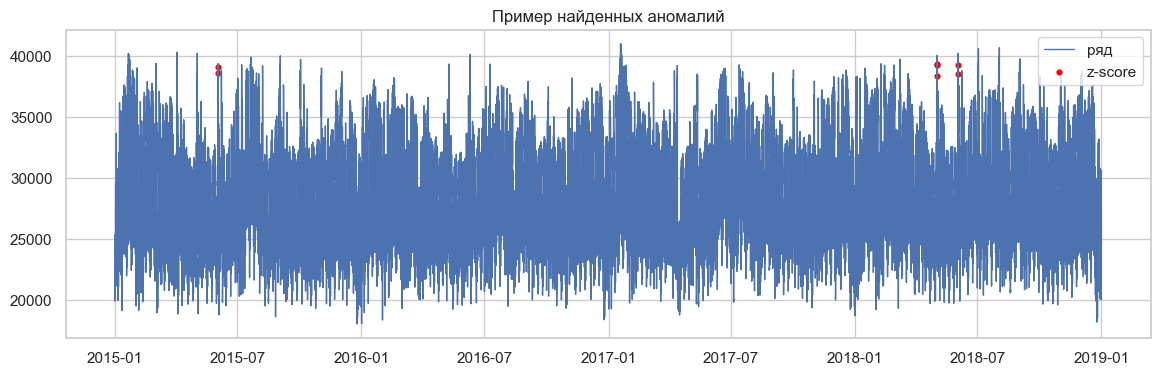

In [23]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(anom["ds"], anom["y"], label="ряд", linewidth=1)
points = anom[anom["anomaly_z"].fillna(False)]
ax.scatter(points["ds"], points["y"], color="red", s=12, label="z-score")
ax.set_title("Пример найденных аномалий")
ax.legend()
plt.show()

На графике z-score выделяет 7 точек - они приходятся на нетипичные часы с резкими провалами или пиками нагрузки. Для более полного анализа аномалий лучше смотреть на IsolationForest, который учитывает сразу несколько признаков.

---

# Задача 4. Пайплайн и тестирование

Запускаю пайплайн из `src/pipeline.py`. Он загружает оба файла, объединяет с погодой Мадрида, интерполирует пропуски, генерирует признаки, обучает бейзлайн и две ML-модели, считает метрики и сохраняет результаты.

In [24]:
import sys
from pathlib import Path
import pandas as pd

sys.path.append(str(Path("..").resolve()))
from src.pipeline import run_pipeline

metrics = run_pipeline()
metrics

{'dataset_rows_raw': 35064,
 'dataset_rows_hourly': 35064,
 'train_rows': 34560,
 'test_rows': 336,
 'target': 'Spain total load actual, hourly',
 'seasonal_naive_24': {'mae': 1780.547619047619,
  'rmse': 2451.3539577528327,
  'mape': 6.695043096221669},
 'linear_regression': {'mae': 348.82071082092403,
  'rmse': 452.38429752828597,
  'mape': 1.2817900324401181,
  'fit_predict_seconds': 0.015715000045020133},
 'random_forest': {'mae': 294.87310975335885,
  'rmse': 390.59826101386,
  'mape': 1.0882434023148955,
  'fit_predict_seconds': 50.129262000031304},
 'statistical_tests': {'random_forest_vs_seasonal_naive_24': {'mean_absolute_error_improvement': 1485.6745092942604,
   'paired_t_stat': 16.604579187963783,
   'paired_t_pvalue': 1.3416063892993844e-45,
   'wilcoxon_stat': 1139.0,
   'wilcoxon_pvalue': 1.7211797031989044e-52,
   'bootstrap_ci_95_low': 1328.1098957655227,
   'bootstrap_ci_95_high': 1668.461169234367},
  'random_forest_vs_linear_regression': {'mean_absolute_error_improv

In [25]:
preds = pd.read_csv("../data/processed/pipeline_predictions.csv", parse_dates=["ds"])

model_metrics = {
    name: value
    for name, value in metrics.items()
    if isinstance(value, dict) and name != "statistical_tests" and "mae" in value
}
run_info = {name: value for name, value in metrics.items() if not isinstance(value, dict)}
stat_tests = pd.DataFrame(metrics["statistical_tests"]).T

display(preds.head())
display(pd.DataFrame(model_metrics).T)
display(pd.Series(run_info, name="value"))
display(stat_tests)

,unique_id,ds,y,seasonal_naive_24,linear_regression,random_forest
0,spain_load,2018-12-18 00:00:00,27932.0,25677.0,28160.708338,28007.322122
1,spain_load,2018-12-18 01:00:00,25927.0,23998.0,26111.792004,26008.471237
2,spain_load,2018-12-18 02:00:00,24876.0,22900.0,24854.532468,24815.274816
3,spain_load,2018-12-18 03:00:00,24389.0,22515.0,24295.414043,24271.317195
4,spain_load,2018-12-18 04:00:00,24433.0,22631.0,24261.894893,24274.132601


,mae,rmse,mape,fit_predict_seconds
seasonal_naive_24,1780.547619,2451.353958,6.695043,NaN
linear_regression,348.820711,452.384298,1.281790,0.015715
random_forest,294.873110,390.598261,1.088243,50.129262


dataset_rows_raw                                 35064
dataset_rows_hourly                              35064
train_rows                                       34560
test_rows                                          336
target                 Spain total load actual, hourly
total_seconds                                51.944994
Name: value, dtype: object

,mean_absolute_error_improvement,paired_t_stat,paired_t_pvalue,wilcoxon_stat,wilcoxon_pvalue,bootstrap_ci_95_low,bootstrap_ci_95_high
random_forest_vs_seasonal_naive_24,1485.674509,16.604579,1.341606e-45,1139.0,1.721180e-52,1328.109896,1668.461169
random_forest_vs_linear_regression,53.947601,5.251806,2.682895e-07,19239.0,3.590581e-07,33.238326,73.874654


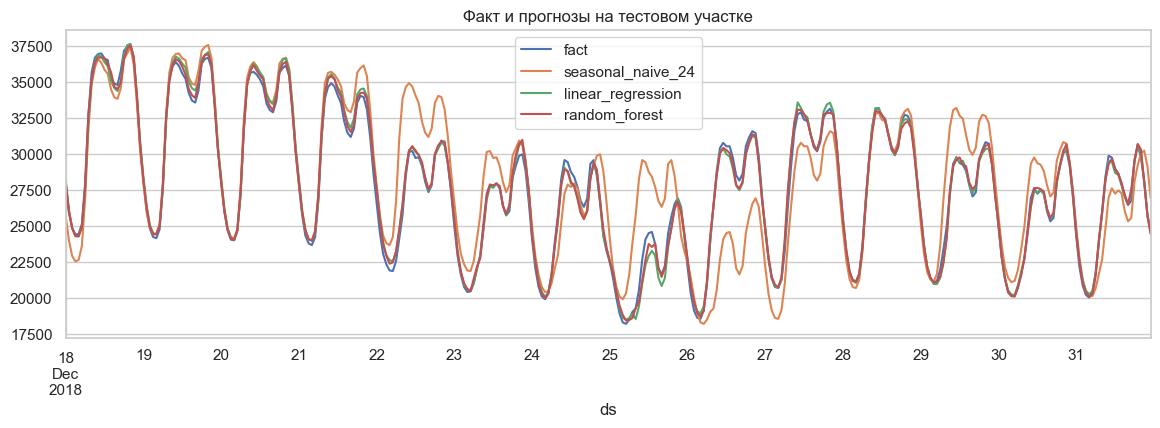

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 4))
preds.plot(x="ds", y="y", ax=ax, label="fact")
for col in ["seasonal_naive_24", "linear_regression", "random_forest"]:
    preds.plot(x="ds", y=col, ax=ax, label=col)
ax.set_title("Факт и прогнозы на тестовом участке")
plt.show()

### Что видно на графике

На графике видно, что сезонный наивный прогноз в целом повторяет суточный профиль, но часто запаздывает и хуже попадает в пики. Линейная регрессия уже ближе к фактическому ряду, потому что использует лаги, календарные признаки и погоду. Random Forest выглядит самым стабильным вариантом: он лучше повторяет форму ряда и меньше ошибается на резких изменениях. Поэтому по графику и по метрикам его логично выбрать как основную модель пайплайна.

## Что проверяется

Я смотрю не только точность, но и время выполнения. Еще добавлена статистическая проверка: она показывает, что улучшение Random Forest относительно простого бейзлайна не случайное.